In [1]:
from pathlib import Path
import random

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

In [2]:
DATASET_NAME = "Fantasy"

PROCESSED_ROOT = Path("processedDatasets") / DATASET_NAME

IMAGE_EXTENSIONS = {".webp",}

BATCH_SIZE = 32
NUM_WORKERS = 2

In [3]:
def scale_0_1_to_neg1_1(x: torch.Tensor) -> torch.Tensor:
    """
    Convert image tensor from [0, 1] to [-1, 1].

    Input shape:  (C, H, W)
    Output shape: (C, H, W)
    """
    return x * 2.0 - 1.0

In [4]:
class ProcessedImageDataset(Dataset):
    """
    Dataset for flattened processed image folders.

    __getitem__ returns:

        original:
            torch.float32 tensor in [0, 1]
            shape: (3, H, W)

        lpips_ready:
            torch.float32 tensor in [-1, 1]
            shape: (3, H, W)
            has 50% chance of horizontal flip
    """

    def __init__(
        self,
        root: str | Path,
        image_extensions: set[str] = IMAGE_EXTENSIONS,
        horizontal_flip_prob: float = 0.5,
    ):
        self.root = Path(root)
        self.image_extensions = {ext.lower() for ext in image_extensions}
        self.horizontal_flip_prob = horizontal_flip_prob

        if not self.root.exists():
            raise FileNotFoundError(f"Dataset folder does not exist: {self.root}")

        self.image_paths = sorted(
            p for p in self.root.iterdir()
            if p.is_file() and p.suffix.lower() in self.image_extensions
        )

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in: {self.root}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index: int):
        path = self.image_paths[index]

        with Image.open(path) as img:
            img = img.convert("RGB")

            # Converts PIL image to float32 torch tensor in [0, 1],
            # with shape (C, H, W).
            original = TF.to_tensor(img).float()

        augmented = original.clone()

        if random.random() < self.horizontal_flip_prob:
            augmented = TF.hflip(augmented)

        lpips_ready = scale_0_1_to_neg1_1(augmented)

        return original, lpips_ready

In [5]:
dataset = ProcessedImageDataset(PROCESSED_ROOT)

len(dataset), dataset[0][0].shape, dataset[0][1].shape

(12814, torch.Size([3, 256, 192]), torch.Size([3, 256, 192]))

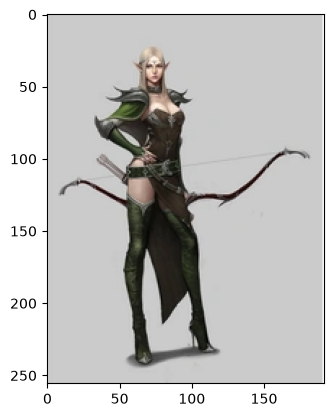

In [6]:
import matplotlib.pyplot as plt
import einx
plt.imshow(einx.id("c h w -> h w c",dataset[0][0]))

In [7]:
import math
import time
from pathlib import Path
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torchvision.utils import make_grid
from IPython.display import display

try:
    import lpips
except ImportError:
    lpips = None
    print("lpips is not installed. Run: pip install lpips")

In [8]:
@dataclass
class VQGANConfig:
    image_height: int = 256
    image_width: int = 192
    image_channels: int = 3

    # Your requested compression factor.
    f: int = 4

    # Your requested codebook embedding dimension.
    z_channels: int = 3

    # Number of discrete codebook entries.
    # This is separate from codebook dimension.
    n_embed: int = 512

    # VQ-VAE/VQGAN commitment weight, beta in the paper-style codebook loss.
    beta: float = 0.25

    # Lightweight architecture.
    base_channels: int = 96
    channel_multipliers: tuple = (1, 2)

    # Loss weights.
    perceptual_weight: float = 1.0
    reconstruction_weight: float = 1.0
    codebook_weight: float = 1.0

    # Adversarial settings.
    disc_start_step: int = 800
    disc_weight: float = 0.8
    disc_factor: float = 1.0
    adaptive_weight_max: float = 1e4

    # Optimizer.
    lr: float = 4.5e-6
    betas: tuple = (0.5, 0.9)

    # Training.
    epochs: int = 100
    batch_size: int = 32
    num_workers: int = 4
    grad_accum_steps: int = 1

    # Logging/checkpointing.
    sample_every_steps: int = 500
    ckpt_every_steps: int = 2_000
    out_dir: str = "runs/vqgan_fantasy"


cfg = VQGANConfig()

assert cfg.image_height % cfg.f == 0
assert cfg.image_width % cfg.f == 0

latent_h = cfg.image_height // cfg.f
latent_w = cfg.image_width // cfg.f

print("Latent grid:", latent_h, "x", latent_w)
print("Latent channels/codebook dimension:", cfg.z_channels)
print("Tokens per image:", latent_h * latent_w)

Latent grid: 64 x 48
Latent channels/codebook dimension: 3
Tokens per image: 3072


In [9]:
vqgan_loader = DataLoader(
    dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()

        self.block = nn.Sequential(
            nn.GroupNorm(num_groups=min(32, channels), num_channels=channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=min(32, channels), num_channels=channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class Downsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
class Encoder(nn.Module):
    def __init__(
        self,
        image_channels: int = 3,
        base_channels: int = 96,
        z_channels: int = 3,
    ):
        super().__init__()

        ch = base_channels

        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ch, kernel_size=3, padding=1),

            ResBlock(ch),
            Downsample(ch, ch * 2),      # 256x192 -> 128x96

            ResBlock(ch * 2),
            Downsample(ch * 2, ch * 4),  # 128x96 -> 64x48

            ResBlock(ch * 4),
            ResBlock(ch * 4),

            nn.GroupNorm(num_groups=min(32, ch * 4), num_channels=ch * 4),
            nn.SiLU(),
            nn.Conv2d(ch * 4, z_channels, kernel_size=1),
            
            # new 1x1 conv layer
        )

    def forward(self, x):
        return self.net(x)

In [12]:
class Decoder(nn.Module):
    def __init__(
        self,
        image_channels: int = 3,
        base_channels: int = 96,
        z_channels: int = 3,
    ):
        super().__init__()

        ch = base_channels
        # new 1x1 conv layer

        self.conv_in = nn.Conv2d(z_channels, ch * 4, kernel_size=3, padding=1)

        self.mid = nn.Sequential(
            ResBlock(ch * 4),
            ResBlock(ch * 4),
        )

        self.up = nn.Sequential(
            Upsample(ch * 4, ch * 2),    # 64x48 -> 128x96
            ResBlock(ch * 2),

            Upsample(ch * 2, ch),        # 128x96 -> 256x192
            ResBlock(ch),

            nn.GroupNorm(num_groups=min(32, ch), num_channels=ch),
            nn.SiLU(),
        )

        self.conv_out = nn.Conv2d(ch, image_channels, kernel_size=3, padding=1)

        

    def forward(self, z):
        
        # use 1x1 conv layer
        h = self.conv_in(z)
        h = self.mid(h)
        h = self.up(h)
        x_hat = self.conv_out(h)
        return torch.tanh(x_hat)

    def get_last_layer(self):
        return self.conv_out.weight

In [13]:
class VectorQuantizer(nn.Module):
    """
    Vector quantizer.

    z shape:
        (B, C, H, W)

    C must equal embedding_dim.
    """

    def __init__(self, n_embed: int, embedding_dim: int, beta: float = 0.25):
        super().__init__()

        self.n_embed = n_embed
        self.embedding_dim = embedding_dim
        self.beta = beta

        self.embedding = nn.Embedding(n_embed, embedding_dim)
        '''self.embedding.weight.data.uniform_(
            -1.0 / n_embed,
            1.0 / n_embed,
        )'''
        self.embedding.weight.data.uniform_(
            -1.0,
            1.0,
        )

    def forward(self, z):
        B, C, H, W = z.shape
        assert C == self.embedding_dim

        # BCHW -> BHWC -> flat
        z_perm = einx.id("b c h w -> b h w c", z).contiguous()
        z_flat = z_perm.view(-1, C)

        # Squared L2 distance to codebook entries.
        distances = (
            torch.sum(z_flat ** 2, dim=1, keepdim=True)
            + torch.sum(self.embedding.weight ** 2, dim=1)
            - 2.0 * torch.matmul(z_flat, self.embedding.weight.t())
        )

        encoding_indices = torch.argmin(distances, dim=1)
        z_q_flat = self.embedding(encoding_indices)

        z_q = z_q_flat.view(B, H, W, C)

        # Paper-style VQ loss:
        # ||sg[z] - z_q||^2 + beta * ||z - sg[z_q]||^2
        codebook_loss = F.mse_loss(z_q, z_perm.detach())
        commitment_loss = F.mse_loss(z_perm, z_q.detach())
        vq_loss = codebook_loss + self.beta * commitment_loss

        # Straight-through estimator.
        z_q = z_perm + (z_q - z_perm).detach()

        # BHWC -> BCHW
        z_q = einx.id("b h w c -> b c h w", z_q).contiguous()

        encoding_indices = encoding_indices.view(B, H, W)

        return z_q, vq_loss, encoding_indices

    @torch.no_grad()
    def codebook_usage(self, indices: torch.Tensor) -> int:
        return indices.unique().numel()

In [14]:
class VQGANAutoencoder(nn.Module):
    def __init__(self, cfg: VQGANConfig):
        super().__init__()

        self.encoder = Encoder(
            image_channels=cfg.image_channels,
            base_channels=cfg.base_channels,
            z_channels=cfg.z_channels,
        )

        # Encoder latent -> codebook latent space.
        self.quant_conv = nn.Conv2d(
            cfg.z_channels,
            cfg.z_channels,
            kernel_size=1,
        )

        self.quantizer = VectorQuantizer(
            n_embed=cfg.n_embed,
            embedding_dim=cfg.z_channels,
            beta=cfg.beta,
        )

        # Codebook latent space -> decoder latent space.
        self.post_quant_conv = nn.Conv2d(
            cfg.z_channels,
            cfg.z_channels,
            kernel_size=1,
        )

        self.decoder = Decoder(
            image_channels=cfg.image_channels,
            base_channels=cfg.base_channels,
            z_channels=cfg.z_channels,
        )

    def encode(self, x, return_prequant: bool = False):
        z = self.encoder(x)

        z = self.quant_conv(z)

        # experimental fix for your collapse.
        z = torch.tanh(z)

        z_q, vq_loss, indices = self.quantizer(z)

        if return_prequant:
            return z_q, vq_loss, indices, z

        return z_q, vq_loss, indices

    def decode(self, z_q):
        z_q = self.post_quant_conv(z_q)
        return self.decoder(z_q)

    def forward(self, x):
        z_q, vq_loss, indices = self.encode(x)
        x_hat = self.decode(z_q)
        return x_hat, vq_loss, indices

    def get_last_layer(self):
        return self.decoder.get_last_layer()

In [15]:
from pathlib import Path
import gc
import torch

# Needed because your VectorQuantizer uses einx.id(...)
import einx

AUTOENCODER_CKPT_PATH = Path("weights") / "autoencoder7-7-27.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint onto CPU so optimizer/discriminator states do not touch GPU memory.
checkpoint = torch.load(
    AUTOENCODER_CKPT_PATH,
    map_location="cpu",
)

# Recover config if present.
# If the checkpoint has cfg saved, use it so architecture matches training.
if isinstance(checkpoint, dict) and "cfg" in checkpoint:
    cfg = VQGANConfig(**checkpoint["cfg"])
else:
    print("No cfg found in checkpoint; using current notebook cfg.")
    cfg = VQGANConfig()

# Build autoencoder architecture.
autoencoder = VQGANAutoencoder(cfg)

# Load only the autoencoder weights.
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    autoencoder.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "autoencoder" in checkpoint:
    autoencoder.load_state_dict(checkpoint["autoencoder"])
else:
    # Handles the case where the file is just autoencoder.state_dict().
    autoencoder.load_state_dict(checkpoint)

# Delete full checkpoint so optimizer/discriminator weights are not kept around.
del checkpoint
gc.collect()

# Move only the autoencoder to GPU.
autoencoder = autoencoder.to(device)
autoencoder.eval()

# Freeze parameters for inference / latent extraction.
for p in autoencoder.parameters():
    p.requires_grad_(False)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded autoencoder from: {AUTOENCODER_CKPT_PATH}")
print(f"Device: {device}")
print(f"cfg.z_channels: {cfg.z_channels}")
print(f"cfg.n_embed: {cfg.n_embed}")
print(f"latent grid for trained size: {cfg.image_height // cfg.f} x {cfg.image_width // cfg.f}")

Loaded autoencoder from: weights/autoencoder7-7-27.pth
Device: cuda
cfg.z_channels: 3
cfg.n_embed: 512
latent grid for trained size: 64 x 48


x: torch.Size([32, 3, 256, 192])
z_e: torch.Size([32, 3, 64, 48])
z_q: torch.Size([32, 3, 64, 48])
indices: torch.Size([32, 64, 48])
x_hat: torch.Size([32, 3, 256, 192])
vq_loss: 0.007192544173449278
codes used: 159 / 512


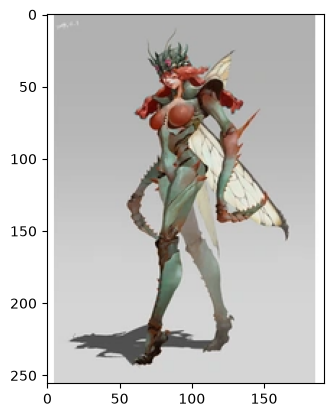

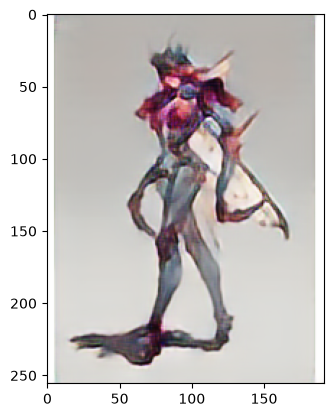

In [16]:
def tensor_neg1_1_to_display_image(x: torch.Tensor, channelFirst=True) -> torch.Tensor:
    """
    Convert a tensor image from [-1, 1] to display-ready [0, 1].

    Input:
        x shape: (3, H, W)

    Output:
        x_display shape: (H, W, 3), clipped to [0, 1]
    """
    x = x.detach().float().cpu()
    x = (x + 1.0) / 2.0
    x = x.clamp(0.0, 1.0)
    if channelFirst:
        x = x.permute(1, 2, 0)
    return x

dataset = ProcessedImageDataset(PROCESSED_ROOT)

vqgan_loader = DataLoader(
    dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

with torch.no_grad():
    original_0_1, x = next(iter(vqgan_loader))
    x = x.to(device, non_blocking=True)

    z_q, vq_loss, indices, z_e = autoencoder.encode(
        x,
        return_prequant=True,
    )
    x_hat = autoencoder.decode(z_q)

print("x:", x.shape)
print("z_e:", z_e.shape)
print("z_q:", z_q.shape)
print("indices:", indices.shape)
print("x_hat:", x_hat.shape)
print("vq_loss:", vq_loss.item())
print("codes used:", indices.unique().numel(), "/", cfg.n_embed)
plt.imshow(tensor_neg1_1_to_display_image(x[0].cpu()))
plt.show()
plt.imshow(tensor_neg1_1_to_display_image(x_hat[0].cpu()))

In [17]:
from pathlib import Path
import torch
from tqdm import tqdm

LATENT_DATASET_NAME = "LatentFantasy"
LATENT_OUTPUT_ROOT = Path("processedDatasets") / LATENT_DATASET_NAME
LATENT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

latent_source_dataset = ProcessedImageDataset(
    PROCESSED_ROOT,
    horizontal_flip_prob=0.0,
)

latent_loader = DataLoader(
    latent_source_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

autoencoder.eval()

saved_count = 0

if reconstruct_latent_dataset := False:
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(latent_loader, desc="Encoding latents")):
            original_0_1, x = batch
    
            # x is [-1, 1], shape (B, 3, 256, 192)
            x = x.to(device, non_blocking=True)
    
            # z is the continuous pre-quantization latent after tanh.
            # Shape: (B, 3, 64, 48)
            z_q, vq_loss, indices, z = autoencoder.encode(
                x,
                return_prequant=True,
            )
    
            z = z.detach().cpu().float()
    
            batch_size = z.shape[0]
    
            for i in range(batch_size):
                source_index = saved_count
                source_path = latent_source_dataset.image_paths[source_index]
    
                out_path = LATENT_OUTPUT_ROOT / f"{source_index:08d}.pth"
    
                torch.save(
                    {
                        "latent": z[i],
                        "source_path": str(source_path),
                        "source_index": source_index,
                        "latent_shape": tuple(z[i].shape),
                        "source_image_shape": (3, cfg.image_height, cfg.image_width),
                        "latent_type": "prequant_tanh",
                        "autoencoder_checkpoint": str(AUTOENCODER_CKPT_PATH),
                    },
                    out_path,
                )
    
                saved_count += 1
    
    print(f"Saved {saved_count} latent files to: {LATENT_OUTPUT_ROOT}")

In [18]:
parameters = {
    "sigma_min" : 0.002,
    "sigma_max" : 80,
    "sigma_data" : 0.5,
    "rho" : 7,
    "P_mean" : -1.2,
    "P_std" : 1.2,
    "N" : 128
}

In [23]:
import os
import glob

latentPathList = glob.glob(str(LATENT_OUTPUT_ROOT / "*"))

def latentPathToImageTensor(imagePath):
    return torch.load(imagePath)['latent']


total_count = 0
total_sum = 0.0
total_sum_sq = 0.0

for p in tqdm(latentPathList):
    x = latentPathToImageTensor(p).float().cpu()

    total_count += x.numel()
    total_sum += x.sum().item()
    total_sum_sq += (x * x).sum().item()

mean = total_sum / total_count
variance = total_sum_sq / total_count - mean ** 2
std = variance ** 0.5

print("dataset mean:", mean)
print("dataset std:", std)


100%|████████████████████████████████████████████████████████████████████████████| 12814/12814 [04:18<00:00, 49.53it/s]


dataset mean: -0.0025474863442257072
dataset std: 0.6384021688081438


In [24]:
parameters['sigma_data'] = std

In [25]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import Resize
import einx

def sampleNoiseVector(sigma, height=64, width=48, channels=3):
    return np.random.normal(
        loc=0.0, 
        scale=sigma, 
        size=(height, width, channels)
    )
def sampleNoisedImage(latentPathList, P_mean = -1.2, P_std = 1.2, height=64, width = 48, device='cpu'):
    idx = random.randrange(0, len(latentPathList))
    filePath = latentPathList[idx]
    
    imageTensor = torch.load(filePath)['latent']
    imageTensor = einx.id("c h w -> h w c", imageTensor)
    logSigma = np.random.normal(loc=P_mean, scale=P_std)
    sigma = np.e ** logSigma
    noiseVec = torch.tensor(sampleNoiseVector(sigma, height=height, width=width))
    
    return imageTensor.to(device), (imageTensor + noiseVec).to(device), torch.tensor([sigma])

def sampleImageBatch(latentPathList, batch_size = 16, device='cpu', height=64, width = 48):
    trueImages = []
    noisedImages = []
    sigmaTensor = []
    classIndices = []
    for _ in range(batch_size):
        trueImage, noisedImage, sigma = sampleNoisedImage(latentPathList, height=height, width = width)
        trueImages.append(trueImage)
        noisedImages.append(noisedImage)
        sigmaTensor.append(sigma)
    return torch.stack(trueImages).float().to(device), torch.stack(noisedImages).float().to(device), torch.stack(sigmaTensor).float().to(device)
newHeight = 64
newWidth = 48
print(newHeight)
print(newWidth)

64
48


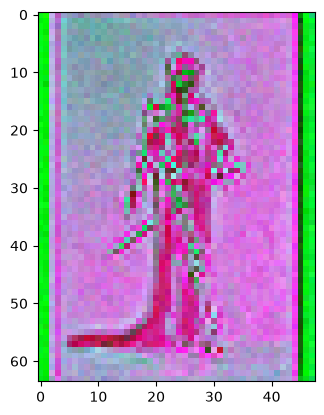

In [28]:
tmp = sampleNoisedImage(latentPathList, height=newHeight, width=newWidth, P_mean=-1.2)[1]
plt.imshow(tensor_neg1_1_to_display_image(tmp, channelFirst=False)) 

In [29]:
def timeIndex(i, sigma_min, sigma_max, rho, N):
    sigmaDiff = sigma_min ** (1 / rho) - sigma_max ** (1 / rho)
    insideParenth = sigma_max ** (1 / rho) + (i / (N - 1)) * sigmaDiff
    return insideParenth ** rho 

def sigmaSchedule(t):
    return t

def computeTimeValues():
    timeIndices = []
    for idx in range(parameters["N"]):
        timeIndices.append(timeIndex(idx, parameters['sigma_min'], parameters['sigma_max'], parameters['rho'], parameters['N']))
    timeIndices.append(0)
    return timeIndices
timeValues = computeTimeValues()
print("t_0 through t_N")
print(f"{', '.join(str(x) for x in timeValues[:10])}...{', '.join(str(x) for x in timeValues[-10:])}")

t_0 through t_N
80.0, 76.62365808076356, 73.37019952280082, 70.23587449514882, 67.21702527325486, 64.3100845316542, 61.51157365787813, 58.818101087459674, 56.22636065990345, 53.73312999548703...0.008196339811421772, 0.006973725158819677, 0.005910883745528433, 0.004990022777169731, 0.004194971294060287, 0.0035110666704456605, 0.0029250465376888125, 0.0024249459985881193, 0.002000000000000003, 0


In [30]:
import einx
import torch.nn as nn
import torch

einx.id("... (hIdx hPatch) (wIdx wPatch) c -> ... (hIdx wIdx) (hPatch wPatch c)", sampleNoisedImage(latentPathList, height=newHeight, width=newWidth)[1], hPatch = 2, wPatch = 3).shape

torch.Size([512, 18])

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LearnedSigmaEmbedding(nn.Module):
    def __init__(self, emb_dim, hidden_dim=None):
        super().__init__()

        hidden_dim = hidden_dim or emb_dim

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, emb_dim),
        )

    def forward(self, sigma):
        sigma = sigma.reshape(-1, 1).float()
        sigma = torch.log(sigma.clamp_min(1e-8))
        return self.net(sigma)


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.norm_in = nn.GroupNorm(32, in_channels)
        self.conv_in = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.sigma_to_scale_shift = nn.Linear(emb_dim, out_channels * 2)

        self.norm_out = nn.GroupNorm(32, out_channels)
        self.conv_out = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, 1)
        )

        nn.init.zeros_(self.conv_out.weight)
        nn.init.zeros_(self.conv_out.bias)

    def forward(self, x, sigma_emb):
        h = self.conv_in(F.silu(self.norm_in(x)))

        scale, shift = self.sigma_to_scale_shift(F.silu(sigma_emb)).chunk(2, dim=1)

        h = self.norm_out(h)
        h = h * (1.0 + scale[:, :, None, None]) + shift[:, :, None, None]

        h = self.conv_out(F.silu(h))

        return self.skip(x) + h


class BottleneckAttention(nn.Module):
    def __init__(self, channels, heads=8):
        super().__init__()

        self.norm = nn.GroupNorm(32, channels)
        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=heads,
            batch_first=True,
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        h = self.norm(x)
        h = h.flatten(2).transpose(1, 2)  # BCHW -> B, HW, C

        h, _ = self.attention(h, h, h, need_weights=False)

        h = h.transpose(1, 2).reshape(batch_size, channels, height, width)

        return x + h


class UNetDiffuser(nn.Module):
    """
    Input/output:
        batched:   (B, H, W, 3)
        unbatched: (H, W, 3)

    For your latent dataset, usually:
        (B, 64, 48, 3)
    """

    def __init__(self, base_channels=192, attention_heads=8):
        super().__init__()

        shallow_channels = base_channels
        middle_channels = base_channels * 2
        deep_channels = base_channels * 4

        sigma_emb_dim = deep_channels

        self.sigma_embedding = LearnedSigmaEmbedding(
            emb_dim=sigma_emb_dim,
            hidden_dim=sigma_emb_dim * 4,
        )

        self.input_projection = nn.Conv2d(
            3,
            shallow_channels,
            kernel_size=3,
            padding=1,
        )

        # Encoder level 1: 64 x 48
        self.encoder_level_1_block_1 = ResBlock(
            shallow_channels,
            shallow_channels,
            sigma_emb_dim,
        )
        self.encoder_level_1_block_2 = ResBlock(
            shallow_channels,
            shallow_channels,
            sigma_emb_dim,
        )

        self.downsample_1_to_2 = nn.Conv2d(
            shallow_channels,
            middle_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # Encoder level 2: 32 x 24
        self.encoder_level_2_block_1 = ResBlock(
            middle_channels,
            middle_channels,
            sigma_emb_dim,
        )
        self.encoder_level_2_block_2 = ResBlock(
            middle_channels,
            middle_channels,
            sigma_emb_dim,
        )

        self.downsample_2_to_bottleneck = nn.Conv2d(
            middle_channels,
            deep_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # Bottleneck: 16 x 12
        self.bottleneck_resblock_1 = ResBlock(
            deep_channels,
            deep_channels,
            sigma_emb_dim,
        )
        self.bottleneck_attention_1 = BottleneckAttention(
            deep_channels,
            heads=attention_heads,
        )
        self.bottleneck_resblock_2 = ResBlock(
            deep_channels,
            deep_channels,
            sigma_emb_dim,
        )
        self.bottleneck_attention_2 = BottleneckAttention(
            deep_channels,
            heads=attention_heads,
        )
        self.bottleneck_resblock_3 = ResBlock(
            deep_channels,
            deep_channels,
            sigma_emb_dim,
        )

        # Decoder level 2: 16 x 12 -> 32 x 24
        self.upsample_bottleneck_to_2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                deep_channels,
                middle_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_2_merge_block = ResBlock(
            middle_channels + middle_channels,
            middle_channels,
            sigma_emb_dim,
        )
        self.decoder_level_2_refine_block = ResBlock(
            middle_channels,
            middle_channels,
            sigma_emb_dim,
        )

        # Decoder level 1: 32 x 24 -> 64 x 48
        self.upsample_2_to_1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                middle_channels,
                shallow_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_1_merge_block = ResBlock(
            shallow_channels + shallow_channels,
            shallow_channels,
            sigma_emb_dim,
        )
        self.decoder_level_1_refine_block = ResBlock(
            shallow_channels,
            shallow_channels,
            sigma_emb_dim,
        )

        self.output_norm = nn.GroupNorm(32, shallow_channels)
        self.output_projection = nn.Conv2d(
            shallow_channels,
            3,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(self.output_projection.weight)
        nn.init.zeros_(self.output_projection.bias)

    def forward(self, x, sigma):
        was_unbatched = False

        if x.ndim == 3:
            x = x.unsqueeze(0)
            was_unbatched = True

        if sigma.ndim == 0:
            sigma = sigma.unsqueeze(0)

        # BHWC -> BCHW
        x = x.permute(0, 3, 1, 2).contiguous()

        sigma_emb = self.sigma_embedding(sigma)

        # Encoder level 1
        x = self.input_projection(x)

        x = self.encoder_level_1_block_1(x, sigma_emb)
        x = self.encoder_level_1_block_2(x, sigma_emb)
        skip_level_1 = x

        # Encoder level 2
        x = self.downsample_1_to_2(x)

        x = self.encoder_level_2_block_1(x, sigma_emb)
        x = self.encoder_level_2_block_2(x, sigma_emb)
        skip_level_2 = x

        # Bottleneck
        x = self.downsample_2_to_bottleneck(x)

        x = self.bottleneck_resblock_1(x, sigma_emb)
        x = self.bottleneck_attention_1(x)
        x = self.bottleneck_resblock_2(x, sigma_emb)
        x = self.bottleneck_attention_2(x)
        x = self.bottleneck_resblock_3(x, sigma_emb)

        # Decoder level 2
        x = self.upsample_bottleneck_to_2(x)

        x = torch.cat([x, skip_level_2], dim=1)
        x = self.decoder_level_2_merge_block(x, sigma_emb)
        x = self.decoder_level_2_refine_block(x, sigma_emb)

        # Decoder level 1
        x = self.upsample_2_to_1(x)

        x = torch.cat([x, skip_level_1], dim=1)
        x = self.decoder_level_1_merge_block(x, sigma_emb)
        x = self.decoder_level_1_refine_block(x, sigma_emb)

        x = self.output_projection(F.silu(self.output_norm(x)))

        # BCHW -> BHWC
        x = x.permute(0, 2, 3, 1).contiguous()

        if was_unbatched:
            x = x.squeeze(0)

        return x

In [51]:
device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

model = UNetDiffuser(
    base_channels=192,
    attention_heads=8,
).to(device_str)

num_params = sum(p.numel() for p in model.parameters())
print(f"params: {num_params:,} ({num_params / 1e6:.2f}M)")

trueImages, noisedImages, sigmaTensor = sampleImageBatch(
    latentPathList,
    batch_size=8,
    device=device_str,
    height=newHeight,
    width=newWidth,
)

with torch.no_grad():
    out = model(noisedImages, sigmaTensor)

print("input: ", noisedImages.shape)
print("output:", out.shape)

assert out.shape == noisedImages.shape

params: 70,588,227 (70.59M)
input:  torch.Size([8, 64, 48, 3])
output: torch.Size([8, 64, 48, 3])


In [52]:
def calcLambda(sigmaTensor, sigma_data=0.5):
    numerator = sigmaTensor ** 2 + sigma_data ** 2
    denom = (sigmaTensor * sigma_data) ** 2
    return numerator / denom

def calcSkipScaling(sigmaTensor, sigma_data = 0.5):
    numerator = sigma_data ** 2
    denom = sigmaTensor ** 2 + sigma_data ** 2
    return numerator / denom

def calcOutputScaling(sigmaTensor, sigma_data=0.5):
    numerator = sigmaTensor * sigma_data
    denom = (sigmaTensor ** 2 + sigma_data ** 2) ** 0.5
    return numerator / denom

def calcInputScaling(sigmaTensor, sigma_data = 0.5):
    numerator = 1
    denom = (sigmaTensor ** 2 + sigma_data ** 2) ** 0.5
    return numerator / denom

def calcNoiseCond(sigmaTensor):
    return 0.25 * torch.log(sigmaTensor)
print(sigmaTensor[:10])
calcInputScaling(sigmaTensor)[:10]

tensor([[0.0465],
        [9.9086],
        [0.1444],
        [0.0804],
        [0.6264],
        [0.9759],
        [0.1578],
        [0.2365]], device='cuda:0')


tensor([[1.9914],
        [0.1008],
        [1.9215],
        [1.9746],
        [1.2477],
        [0.9120],
        [1.9073],
        [1.8080]], device='cuda:0')

In [53]:
def calculateLoss(denoisingModel, trueImages, noisedImages, sigmaTensor):
    lamb = calcLambda(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_skip = calcSkipScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_out = calcOutputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_in = calcInputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_noise = calcNoiseCond(sigmaTensor)
    
    # So that it can be broadcasted to be multiplied element wise against images in the batch
    c_in_expl = c_in.unsqueeze(-1).unsqueeze(-1)
    c_skip_expl = c_skip.unsqueeze(-1).unsqueeze(-1)
    c_out_expl = c_out.unsqueeze(-1).unsqueeze(-1)
    
    modelImageInput = c_in_expl * noisedImages
    modelOutput = denoisingModel(modelImageInput, c_noise)
    
    effectiveTrainingTarget = (1 / c_out_expl) * (trueImages - c_skip_expl * noisedImages)
    # These three lines if you follow the suggested expressions in the paper simplifies to
    # MSE(modelOutput, effectiveTrainingTarget) * some_constant_dependent_on_image_dimensions
    # Since lambda and c_out**2 are inverses, and the rest is a mean over the sum of your pixel errors
    # rather than the sum of your 
    interm = (modelOutput - effectiveTrainingTarget) ** 2
    normedDiff = torch.sum(einx.id("... h w c -> ... (h w c)", interm), dim=-1, keepdim=True)
    weightedLoss = lamb * (c_out ** 2) * normedDiff
    return torch.mean(weightedLoss)
model.to('cpu')
loss = calculateLoss(model, trueImages.to('cpu'), noisedImages.to('cpu'), sigmaTensor.to('cpu'))
print(loss)

tensor(9280.8320, grad_fn=<MeanBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9374554..2.7301013].


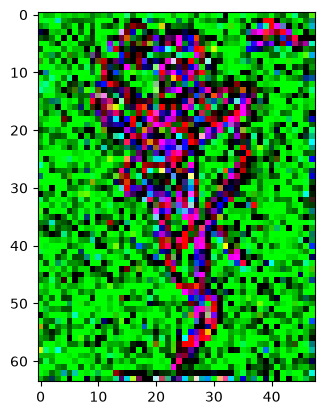

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7146997..1.5936596].


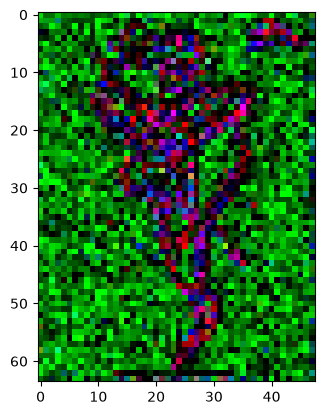

In [54]:
def calcTrueDenoised(denoisingModel, noisedImages, sigmaTensor):
    c_skip = calcSkipScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_out = calcOutputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_in = calcInputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_noise = calcNoiseCond(sigmaTensor)
    
    # So that it can be broadcasted to be multiplied element wise against images in the batch
    c_in_expl = c_in.unsqueeze(-1).unsqueeze(-1)
    c_skip_expl = c_skip.unsqueeze(-1).unsqueeze(-1)
    c_out_expl = c_out.unsqueeze(-1).unsqueeze(-1)

    return c_skip_expl * noisedImages + c_out_expl * denoisingModel(c_in_expl * noisedImages, c_noise)

def displayDenoisingProgress(model, noiseRange = (0.4, 0.6), device='cuda:0'):
    model.to(device)
    trueImages, noisedImages, sigmaTensor = sampleImageBatch(latentPathList, device=device, height=newHeight, width=newWidth, batch_size=64)
    for idx in range(sigmaTensor.shape[0]):
        if sigmaTensor[idx][0] > noiseRange[0] and sigmaTensor[idx][0] < noiseRange[1]:
            plt.imshow(noisedImages[idx].cpu().numpy())
            plt.show()
            with torch.no_grad():
                denoised = calcTrueDenoised(model, noisedImages[idx], sigmaTensor[idx])
            plt.imshow(denoised.cpu().numpy())
            plt.show()
            break
displayDenoisingProgress(model)

100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 81.42it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2345562..2.4848154].


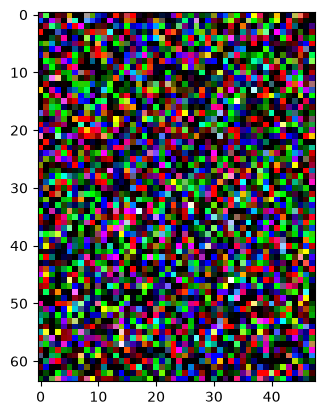

In [55]:
from tqdm import tqdm
timeValues = computeTimeValues()
def HeunSampleImage(denoisingModel, timeValues, device='cpu'):
    denoisingModel.to(device)
    generatedImages = []

    # Implicit assumption that sigma(t)=t and s(t) = 1 to make partial derivative calcs easy
    
    initImage = sampleNoiseVector(timeValues[0], height=newHeight, width=newWidth, channels=3)
    imgTensor = torch.tensor(initImage).float().to(device)
    generatedImages.append(imgTensor.detach().cpu().numpy())
    for i in tqdm(range(len(timeValues) - 1)):
        timeVal = timeValues[i]
        sigmaTensor = torch.tensor([timeVal]).float().to(device)
        denoisedPred = calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)
        dxdt = (imgTensor - denoisedPred) / timeVal
        imgTensorClone = imgTensor.clone()
        imgTensor = imgTensor + (timeValues[i + 1] - timeVal) * dxdt
        generatedImages.append(imgTensor.detach().cpu().numpy())

        if timeValues[i+1] != 0:
            sigmaTensor = torch.tensor([timeValues[i+1]]).float().to(device)
            dxdtprime = (imgTensor - calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)) / timeValues[i+1]
            imgTensor = imgTensorClone + (timeValues[i+1] - timeValues[i]) * (0.5 * dxdt + 0.5 * dxdtprime)

    return imgTensor, generatedImages
with torch.no_grad():
    aaa, generatedImages = HeunSampleImage(model, timeValues, 'cuda:0')
plt.imshow(aaa.cpu().numpy())

In [57]:
for obj in dir():
    if isinstance(globals()[obj], torch.Tensor):
        del globals()[obj]
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

import torch.optim as optim
model = UNetDiffuser(
    base_channels=192,
    attention_heads=8,
).to(device_str)

if loadFromState := False:
    ckpt = torch.load("ckpt-adaln.pt", map_location="cpu")  # or "cuda" if you want it on GPU
    
    model.load_state_dict(ckpt["model"])
    
    model.to('cuda:0')
    optimizer = optim.AdamW(model.parameters(), lr = 1e-4)
    
    # Restore model and optimizer states
    optimizer.load_state_dict(ckpt["optimizer"])
else:
    model.to('cuda:0')
    optimizer = optim.AdamW(model.parameters(), lr = 1e-4)

In [58]:
total_params = sum(param.numel() for param in model.parameters())
print(total_params)

70588227


In [59]:
import copy
import torch
import matplotlib.pyplot as plt


ema_model = copy.deepcopy(model).eval()
for p in ema_model.parameters():
    p.requires_grad_(False)


@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.mul_(decay).add_(p, alpha=1.0 - decay)


@torch.no_grad()
def decode_hwc_latent(prequant_hwc, autoencoder):
    """
    prequant_hwc: (H, W, C)
    returns decoded image in [-1, 1], shape (1, 3, H*4, W*4)
    """
    z = prequant_hwc.permute(2, 0, 1).unsqueeze(0).contiguous()
    z = z.to(next(autoencoder.parameters()).device)

    z_q, _, indices = autoencoder.quantizer(z)
    x_hat = autoencoder.decode(z_q)

    return x_hat, z_q, indices


def show_hwc_latent(z, title=None):
    """
    z: (H, W, C), min-max scaled for display
    """
    z = z.detach().cpu().float()
    z = (z - z.min()) / (z.max() - z.min() + 1e-8)

    plt.imshow(z.numpy())
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def show_tensor_image(x, title=None):
    """
    x: (1, 3, H, W) or (3, H, W), in [-1, 1]
    """
    if x.ndim == 4:
        x = x[0]

    x = ((x.detach().cpu() + 1.0) / 2.0).clamp(0, 1)
    x = x.permute(1, 2, 0).numpy()

    plt.imshow(x)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 60400
loss: 1666.3867
min loss: 1238.7305
grad norm: 2361.0623
elapsed: 14966.797 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 92.16it/s]


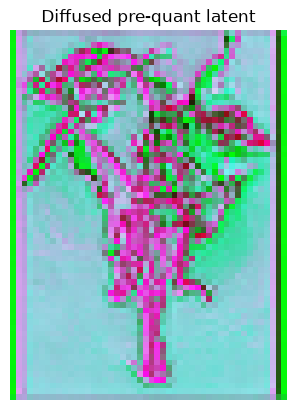

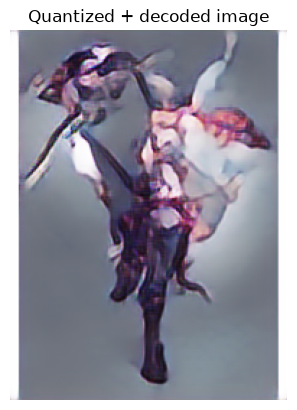

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 60600
loss: 1603.0457
min loss: 1238.7305
grad norm: 2301.7075
elapsed: 15013.665 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 90.26it/s]


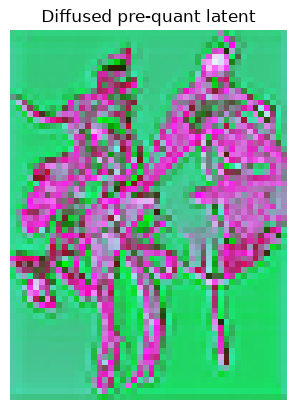

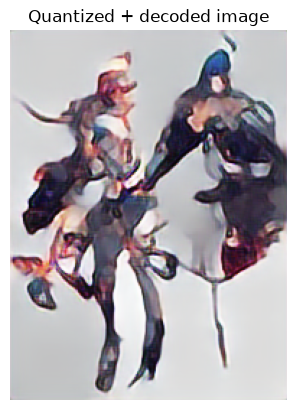

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 60800
loss: 1907.2139
min loss: 1238.7305
grad norm: 1650.3206
elapsed: 15054.021 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 89.61it/s]


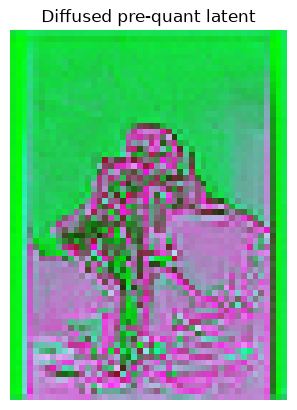

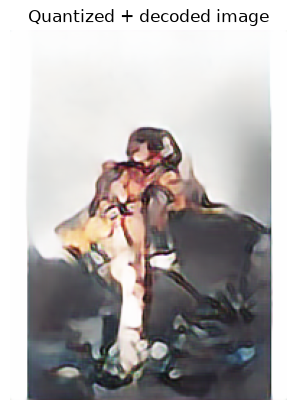

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 61000
loss: 1947.8495
min loss: 1238.7305
grad norm: 1953.2123
elapsed: 15097.897 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 86.47it/s]


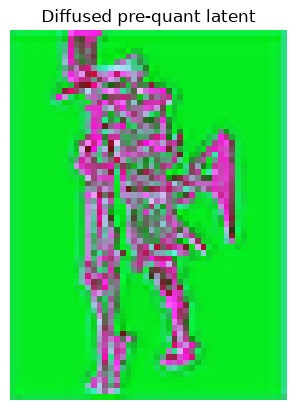

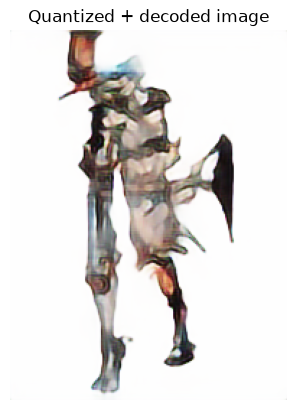

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 61200
loss: 2244.8774
min loss: 1238.7305
grad norm: 2703.6858
elapsed: 15159.903 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 80.45it/s]


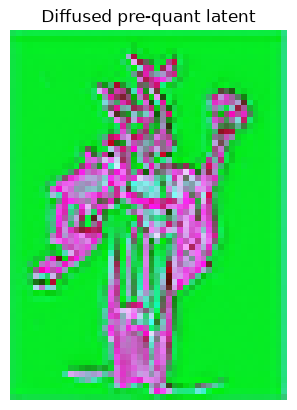

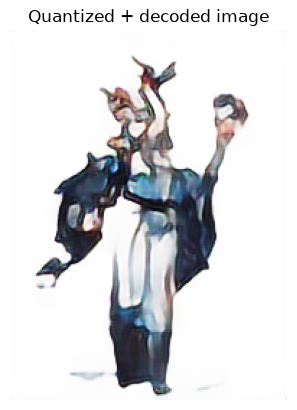

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 61400
loss: 2138.2888
min loss: 1238.7305
grad norm: 1932.2788
elapsed: 15207.198 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 87.17it/s]


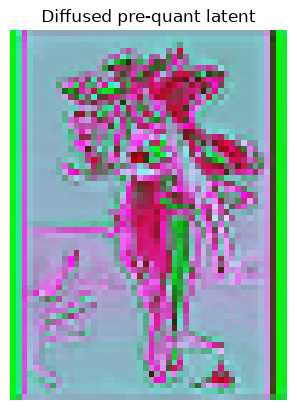

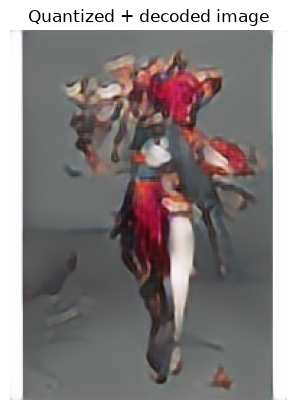

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 61600
loss: 1870.2700
min loss: 1238.7305
grad norm: 2221.0515
elapsed: 15250.530 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 93.42it/s]


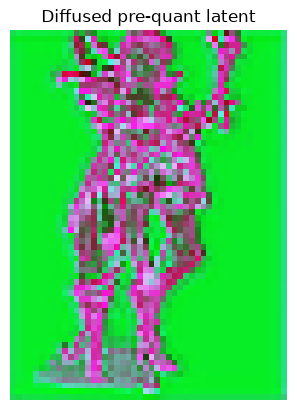

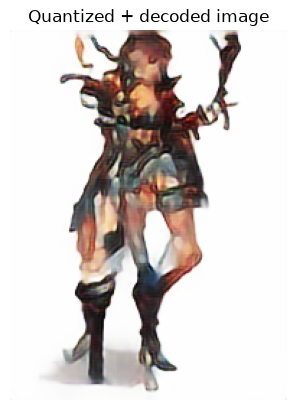

alloc:1444MiB
reserved:2540MiB
max_alloc:2330MiB

epoch: 61800
loss: 2859.9482
min loss: 1238.7305
grad norm: 4264.3008
elapsed: 15292.947 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 96.67it/s]


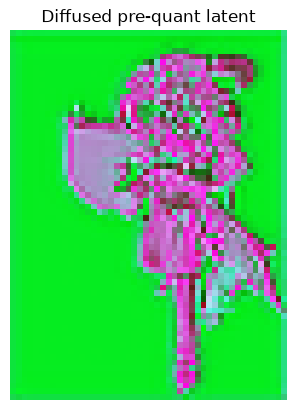

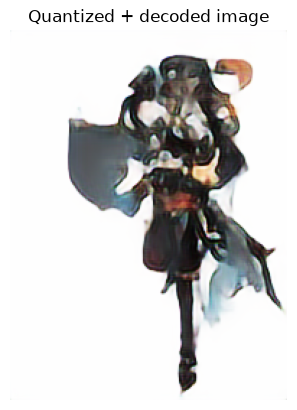

In [ ]:
import time

timeValues = computeTimeValues()
minLoss = 1e1000

device_str = "cuda:0"

model.to(device_str)
ema_model.to(device_str)
autoencoder.to(device_str)

model.train()
ema_model.eval()
autoencoder.eval()

for p in autoencoder.parameters():
    p.requires_grad_(False)

max_grad = 5000
minSaveInterval = 1000
epochsSinceLastSave = 0
saveIfLossBelow = 2000
batch_size = 8
printEvery = 200

imageGenProgress = []

run_name = f"train_{time.strftime('%Y%m%d_%H%M%S')}"
startTime = time.time()

for epoch in range(1000000):
    trueImages, noisedImages, sigmaTensor = sampleImageBatch(
        latentPathList,
        batch_size=batch_size,
        device=device_str,
        height=newHeight,
        width=newWidth,
    )

    optimizer.zero_grad(set_to_none=True)

    loss = calculateLoss(
        model,
        trueImages,
        noisedImages,
        sigmaTensor,
    )

    loss.backward()

    total_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_grad,
    )

    optimizer.step()
    update_ema(ema_model, model, decay=0.999)

    epochsSinceLastSave += 1

    if loss.item() < minLoss:
        minLoss = loss.item()

    if loss.item() < saveIfLossBelow and epochsSinceLastSave > minSaveInterval:
        ckpt = {
            "model": model.state_dict(),
            "ema_model": ema_model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "loss": float(loss.item()),
            "minLoss": float(minLoss),
            "run_name": run_name,
        }

        try:
            torch.save(ckpt, "ckpt-adaln.pt")
        except KeyboardInterrupt:
            print("Delaying keyboard interrupt to save checkpoint")
            torch.save(ckpt, "ckpt-adaln.pt")

        epochsSinceLastSave = 0

    if epoch % printEvery == 0:
        cuda_mem_str = (
            f"alloc:{torch.cuda.memory_allocated() // (1024**2)}MiB\n"
            f"reserved:{torch.cuda.memory_reserved() // (1024**2)}MiB\n"
            f"max_alloc:{torch.cuda.max_memory_allocated() // (1024**2)}MiB\n"
        )

        print(cuda_mem_str)
        print(
            f"""epoch: {epoch}
loss: {loss.item():.4f}
min loss: {minLoss:.4f}
grad norm: {float(total_norm):.4f}
elapsed: {time.time() - startTime:.3f} secs"""
        )

        with torch.no_grad():
            prequantizedDiffusedLatent, _ = HeunSampleImage(
                ema_model,
                timeValues,
                device_str,
            )

            decoded_image, z_q, indices = decode_hwc_latent(
                prequantizedDiffusedLatent,
                autoencoder,
            )

        show_hwc_latent(prequantizedDiffusedLatent, title="Diffused pre-quant latent")
        show_tensor_image(decoded_image, title="Quantized + decoded image")

        imageGenProgress.append(
            {
                "epoch": epoch,
                "latent": prequantizedDiffusedLatent.detach().cpu(),
                "decoded": decoded_image.detach().cpu(),
                "codes_used": indices.unique().numel(),
            }
        )